# Explore here

It's recommended to use this notebook for exploration purposes.

Estado de la conexión: 200 OK

Se consuguieron 27 tablas.

Filas encontradas antes de la limpieza: 101

Filas finales después de la limpieza: 100

DataFrame Limpio:
  Rank                 Song                    Artist  Streams (billions)  \
0    1    "Blinding Lights"                The Weeknd               5.079   
1    2       "Shape of You"                Ed Sheeran               4.596   
2    3            "Starboy"  The Weeknd and Daft Punk               4.147   
3    4    "Sweater Weather"         The Neighbourhood               4.095   
4    5  "Someone You Loved"             Lewis Capaldi               4.090   

  Date released  
0    2019-11-29  
1    2017-01-06  
2    2016-09-21  
3    2012-12-03  
4    2018-11-08  
Datos insertados en la tabla 'most_streamed_songs' de la base de datos 'spotify_top_streams.db'.
Verificación: La tabla contiene 100 registros.


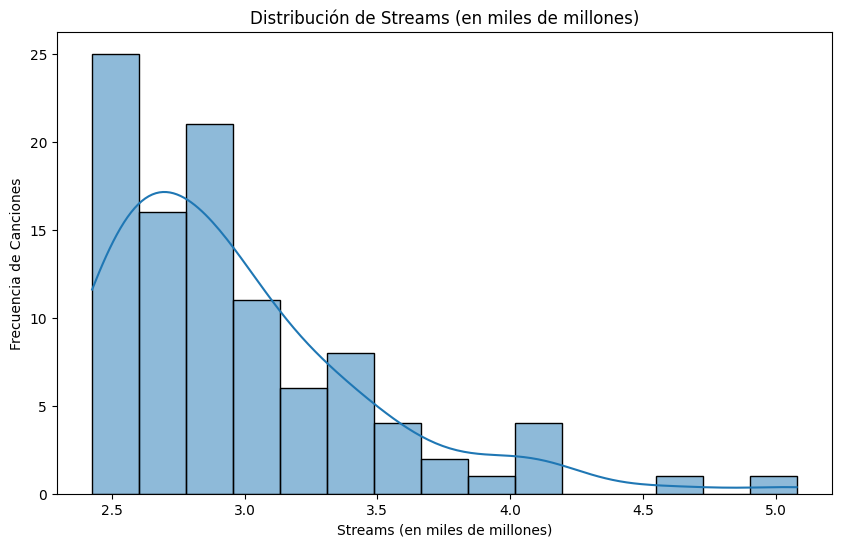

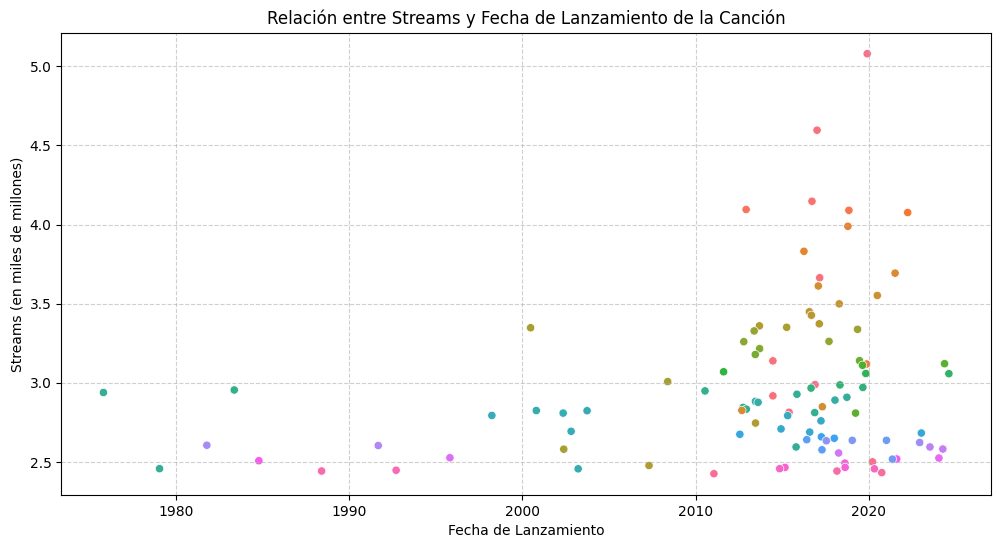

/tmp/ipykernel_4056/573848657.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.index, y=top_artists.values, palette="viridis")


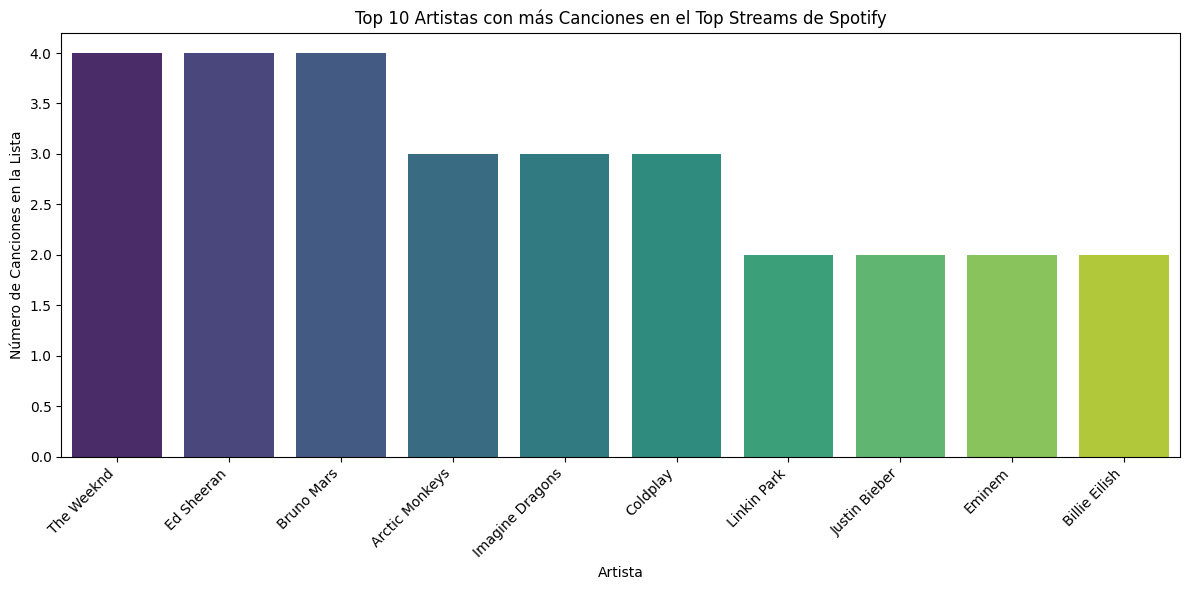

In [29]:
import os
from bs4 import BeautifulSoup
import requests
import time
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import io

#PASO 1 
''' Instalar pip install pandas requests lxml '''

#PASO 2

url = "https://en.wikipedia.org/wiki/List_of_most-streamed_songs_on_Spotify"
headers = {"User-Agent": "mi-scraper/0.1 (+https://tusitio.example)"}
resp = requests.get(url, headers=headers)
resp.raise_for_status()
html = io.StringIO(resp.text)

if resp.status_code != 200:
    raise Exception(f"Error al acceder a la página: Código {resp.status_code}")

print(f"Estado de la conexión: {resp.status_code} OK")

#PASO 3

tables = pd.read_html(html)
print(f"\nSe consuguieron {len(tables)} tablas.")

'''Se inspecciona 1 tabla'''

df = tables[0]
print(f"\nFilas encontradas antes de la limpieza: {len(df)}")


#PASO 4


df.columns = ["Rank", "Song", "Artist", "Streams (billions)", "Date released", "Reference"]

# Limpieza de Corchetes en Múltiples Columnas

cols_to_clean = ["Song", "Artist", "Streams (billions)", "Date released", "Reference"]
df[cols_to_clean] = df[cols_to_clean].replace(r"\[.*?\]", "", regex=True)

# Conversión de Tipos y Filtrado

df["Streams (billions)"] = pd.to_numeric(df["Streams (billions)"], errors="coerce")

#Eliminar las filas donde 'Streams (billions)' son (NaN)

df.dropna(subset=["Streams (billions)"], inplace=True)

# Convertir fechas a datetime. Los errores se convierten a NaT (Not a Time)

df["Date released"] = pd.to_datetime(df["Date released"], errors="coerce")

# Limpieza final de columnas innecesarias

df.drop(columns=["Reference"], inplace=True)

# Reiniciar el índice después de eliminar filas

df.reset_index(drop=True, inplace=True)

print(f"\nFilas finales después de la limpieza: {len(df)}")
print("\nDataFrame Limpio:")
print(df.head())

#PASO 5

# Almacenar los datos en sqlite 
db_name = "spotify_top_streams.db"
table_name = "most_streamed_songs"

# Conexión y Creación de la BD

conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# 5.2. Inserción de Valores (Usando el método de Pandas)

df.to_sql(table_name, conn, if_exists='replace', index=False)


# Verificación y Cierre

print(f"Datos insertados en la tabla '{table_name}' de la base de datos '{db_name}'.")
cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
count = cursor.fetchone()[0]
print(f"Verificación: La tabla contiene {count} registros.")

conn.close()

#PASO 6

# Visualización 1: Distribución de Streams

plt.figure(figsize=(10, 6))
sns.histplot(df["Streams (billions)"], kde=True, bins=15)
plt.title("Distribución de Streams (en miles de millones)")
plt.xlabel("Streams (en miles de millones)")
plt.ylabel("Frecuencia de Canciones")
plt.show()

# Visualización 2: Streams vs. Fecha de Lanzamiento

plt.figure(figsize=(12, 6))
sns.scatterplot(x=df["Date released"], y=df["Streams (billions)"], hue=df["Artist"], legend=False)
plt.title("Relación entre Streams y Fecha de Lanzamiento de la Canción")
plt.xlabel("Fecha de Lanzamiento")
plt.ylabel("Streams (en miles de millones)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Visualización 3: Top 10 Artistas por Número de Canciones en el Top
top_artists = df["Artist"].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_artists.index, y=top_artists.values, palette="viridis")
plt.title("Top 10 Artistas con más Canciones en el Top Streams de Spotify")
plt.xlabel("Artista")
plt.ylabel("Número de Canciones en la Lista")
plt.xticks(rotation=45, ha='right')
plt.tight_layout() 
plt.show()
